In [1]:
import numpy as np

In [2]:
folder_path = r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD"

int_id_data = np.load(folder_path + r"\int_id_data.npy", allow_pickle=True)
attack_labels = np.load(folder_path + r"\attack_labels.npy", allow_pickle=True)


int_id_data_test = np.load(folder_path + r"\int_id_data_test.npy", allow_pickle=True)
attack_labels_test = np.load(folder_path + r"\attack_labels_test.npy", allow_pickle=True)

In [3]:
print(int_id_data)

print(attack_labels)

[array([[  5, 225, 137, ..., 255, 236, 128],
        [  2, 139,   0, ...,   0,   0,   0],
        [  0, 208,  10, ...,   3,   7,   0],
        ...,
        [  0,  51,  23, ..., 128,   7, 208],
        [  2, 116,  81, ..., 124, 142, 185],
        [  6, 224,  89, ...,   0, 255, 255]])
 array([[  5, 225, 137, ..., 255, 236, 128],
        [  2, 139,   0, ...,   0,   0,   0],
        [  0, 208,  10, ...,   3,   7,   0],
        ...,
        [  0,  51,  23, ..., 128,   7, 208],
        [  2, 116,  81, ..., 124, 142, 185],
        [  6, 224,  89, ...,   0, 255, 255]])
 array([[  2, 225,   0, ...,   0,   0,   4],
        [  3,  84,  32, ...,   6,  44,   0],
        [  5, 225, 137, ..., 255, 176, 128],
        ...,
        [  0,  51,   0, ...,   0,   7, 208],
        [  2, 116,   0, ..., 124, 142, 185],
        [  6, 224,  89, ...,   0, 255, 255]])
 array([[  2, 225,   0, ...,   0,   0,   4],
        [  3,  84,  32, ...,   6,  44,   0],
        [  5, 225, 137, ..., 255, 176, 128],
        ...,


In [4]:
# Search for 'T' in the merged attack_labels list
t_positions = [np.flatnonzero(labels == 'T') for labels in attack_labels]
t_counts = [pos.size for pos in t_positions]

for idx, count in enumerate(t_counts):
    if count:
        print(f"list element {idx}: {count} 'T' labels, first positions {t_positions[idx][:10].tolist()}")

print("Total 'T' labels:", sum(t_counts))

list element 0: 1669 'T' labels, first positions [43, 62, 89, 98, 133, 152, 182, 192, 227, 245]
list element 1: 1669 'T' labels, first positions [42, 60, 86, 94, 128, 146, 175, 184, 218, 235]
list element 2: 1713 'T' labels, first positions [9, 16, 49, 64, 101, 119, 167, 178, 208, 219]
list element 3: 1713 'T' labels, first positions [9, 15, 47, 61, 97, 114, 161, 171, 200, 210]
list element 4: 1012 'T' labels, first positions [13, 39, 59, 82, 105, 135, 153, 186, 208, 241]
list element 5: 1012 'T' labels, first positions [13, 38, 57, 79, 101, 130, 147, 179, 200, 232]
list element 6: 34 'T' labels, first positions [208, 493, 639, 916, 1196, 1343, 1614, 1878, 2155, 2311]
list element 7: 34 'T' labels, first positions [207, 491, 636, 912, 1191, 1337, 1607, 1870, 2146, 2301]
list element 8: 1956 'T' labels, first positions [6, 28, 60, 74, 121, 136, 167, 182, 208, 223]
list element 9: 1956 'T' labels, first positions [6, 27, 58, 71, 117, 131, 161, 175, 200, 214]
list element 10: 2513 'T' lab

In [5]:
import builtins
import numpy as np


def sliding_windows_id_data(samples, labels, window_size=32, step=2, attack_labels=('T', 'D', 'F', 'S')):
    n = len(samples)

    if isinstance(attack_labels, str):
        attack_labels = (attack_labels,)

    windows = []
    window_labels = []
    next_id_datas = []
    

    for start in range(0, n - window_size, step):
        end = start + window_size
        window_slice = labels[start:end]

        windows.append(samples[start:end])
        next_id_datas.append(samples[end])

        matching_attack = builtins.next(
            (label for label in attack_labels if label in window_slice),
            'R'
        )
        window_labels.append(matching_attack)

    return (
        np.array(windows, dtype=np.uint8),
        np.array(next_id_datas, dtype=object),
        np.array(window_labels, dtype=object)
    )

In [6]:
len(int_id_data)

28

In [7]:
windows, windowed_labels = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data[i], attack_labels[i])
    windows.extend(windows_batch)
    windowed_labels.extend(windowed_labels_batch)


In [8]:
t_positions = np.flatnonzero(windowed_labels == 'T')
print(f"Found {t_positions.size} 'T' labels in windowed_labels")
if t_positions.size:
    print("First positions:", t_positions[:20].tolist())

Found 0 'T' labels in windowed_labels


In [9]:
windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels), 2), dtype=np.uint8)
attack_onehot[windowed_labels == 'R', 0] = 1
attack_onehot[windowed_labels == 'T', 1] = 1

print(attack_onehot[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]]


In [10]:
windows_test, windowed_labels_test = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data_test[i], attack_labels_test[i])
    windows_test.extend(windows_batch)
    windowed_labels_test.extend(windowed_labels_batch)

In [11]:
windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test), 2), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'R', 0] = 1
attack_onehot_test[windowed_labels_test == 'T', 1] = 1

print(attack_onehot_test[:10])

[[0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]]


In [12]:
windows = np.array(windows)
windows_test = np.array(windows_test)

In [ ]:
import tensorflow as tf
import tensorflow as tf

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 10, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(2, activation='softmax'))

In [42]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(windows, attack_onehot, epochs=5, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 237s 264ms/step - accuracy: 0.9043 - loss: 0.2336 - val_accuracy: 0.9728 - val_loss: 0.0702
Epoch 2/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 239s 268ms/step - accuracy: 0.9902 - loss: 0.0266 - val_accuracy: 0.9094 - val_loss: 0.2767
Epoch 3/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 249s 279ms/step - accuracy: 0.9935 - loss: 0.0173 - val_accuracy: 0.9688 - val_loss: 0.0952
Epoch 4/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 267s 299ms/step - accuracy: 0.9954 - loss: 0.0123 - val_accuracy: 0.9739 - val_loss: 0.0930
Epoch 5/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 252s 282ms/step - accuracy: 0.9966 - loss: 0.0091 - val_accuracy: 0.9534 - val_loss: 0.1661


In [43]:
loss, accuracy = model.evaluate(windows_test, attack_onehot_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.2876
Test accuracy: 0.9246


In [24]:
label_map = np.array(['R', 'T'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(windows_test))
print(recovered_labels[:20])

17407/17407 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step
['T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T'
 'T' 'T']


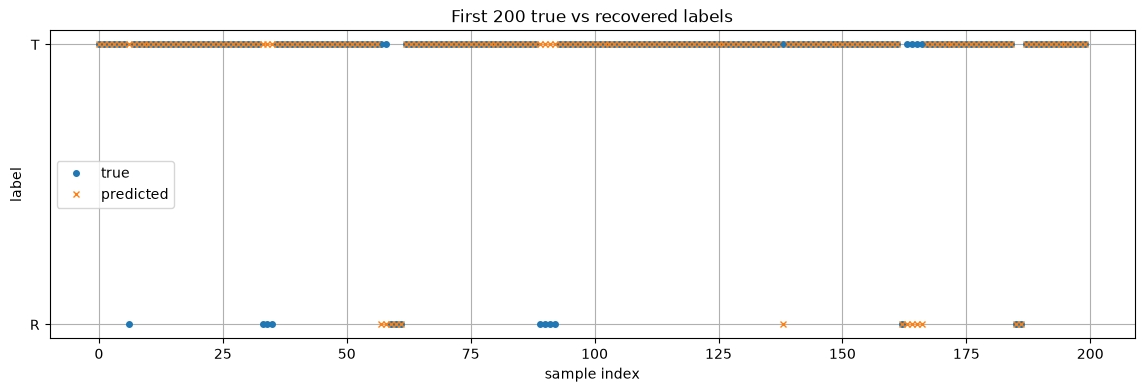

In [25]:
true_labels = np.array(onehot_to_labels(attack_onehot_test))
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

# Predictions
y_pred_probs = model.predict(windows_test)
y_pred = onehot_to_labels(y_pred_probs)
y_true = onehot_to_labels(attack_onehot_test)

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
weighted_precision = precision_score(
    y_true, y_pred, average="weighted", zero_division=0
)
weighted_recall = recall_score(
    y_true, y_pred, average="weighted", zero_division=0
)
weighted_f1 = f1_score(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {weighted_precision:.4f}")
print(f"Weighted recall: {weighted_recall:.4f}")
print(f"Weighted F1 score: {weighted_f1:.4f}")
print()

# Classification report
print("Classification report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=label_map,
        target_names=label_map,
        zero_division=0,
        digits=2,        # Matches the example formatting
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=label_map)

print("Confusion matrix:")
print(pd.DataFrame(cm, index=label_map, columns=label_map))
print()

# Calculate FPR and FNR
tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(
    fps,
    fps + tns,
    out=np.zeros_like(fps, dtype=float),
    where=(fps + tns) != 0,
)

fnr = np.divide(
    fns,
    fns + tps,
    out=np.zeros_like(fns, dtype=float),
    where=(fns + tps) != 0,
)

print("False positive rate per class:")
for label, rate in zip(label_map, fpr):
    print(f"  {label}: {rate:.4f}")

print()
print("False negative rate per class:")
for label, rate in zip(label_map, fnr):
    print(f"  {label}: {rate:.4f}")

17407/17407 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step
Accuracy: 0.9378
Weighted precision: 0.9438
Weighted recall: 0.9378
Weighted F1 score: 0.9391

Classification report:
              precision    recall  f1-score   support

           R       0.98      0.93      0.96    412496
           T       0.83      0.96      0.89    144502

    accuracy                           0.94    556998
   macro avg       0.91      0.94      0.92    556998
weighted avg       0.94      0.94      0.94    556998

Confusion matrix:
        R       T
R  384320   28176
T    6473  138029

False positive rate per class:
  R: 0.0448
  T: 0.0683

False negative rate per class:
  R: 0.0683
  T: 0.0448


In [ ]:
"""import os
from tensorflow import keras

os.makedirs("saved_models", exist_ok=True)
model.save(os.path.join("saved_models", "HCRL_model_2.h5"))
print("Saved model to saved_models/HCRL_model_2.h5")"""
exit()
hello()

NameError: name 'hello' is not defined

: 

In [ ]:
import numpy as np

windows = np.expand_dims(windows, axis=-1)
windows_test = np.expand_dims(windows_test, axis=-1)

def representative_dataset():
    for i in range(100):
        yield [windows[i:i+1].astype(np.float32)]

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("cnn_int8_2.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\nb0801\AppData\Local\Temp\tmp_wfzlxuh\assets


INFO:tensorflow:Assets written to: C:\Users\nb0801\AppData\Local\Temp\tmp_wfzlxuh\assets


Saved artifact at 'C:\Users\nb0801\AppData\Local\Temp\tmp_wfzlxuh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 10, 1), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2128368032016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368032592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368029904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368032208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368031440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368031824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368033168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368031056: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


: 

In [ ]:
interpreter = tf.lite.Interpreter(
    model_path="cnn_int8_2.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
sample = windows[0:1].astype(np.float32)

scale, zero_point = input_details[0]["quantization"]

sample_int8 = (sample / scale + zero_point).astype(np.int8)

In [ ]:
import tensorflow as tf
import numpy as np
import time

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

# ----------------------------
# Load TFLite model
# ----------------------------

interpreter = tf.lite.Interpreter(model_path="cnn_int8_2.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero = input_details[0]["quantization"]
output_scale, output_zero = output_details[0]["quantization"]

# ----------------------------
# Run inference
# ----------------------------

predictions = []

start = time.perf_counter()

for sample in windows_test:

    sample = np.expand_dims(sample, axis=0).astype(np.float32)

    # Quantize input if needed
    if input_details[0]["dtype"] == np.int8:
        sample = (sample / input_scale + input_zero).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], sample)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])

    # Dequantize output
    if output_details[0]["dtype"] == np.int8:
        output = (output.astype(np.float32) - output_zero) * output_scale

    predictions.append(np.argmax(output))

end = time.perf_counter()

print(f"Average inference time: {(end-start)/len(windows_test)*1000:.3f} ms")

predictions = np.array(predictions)

# ----------------------------
# Convert one-hot labels
# ----------------------------

y_true = np.argmax(attack_onehot_test, axis=1)

# ----------------------------
# Accuracy
# ----------------------------

accuracy = accuracy_score(y_true, predictions)

print(f"\nTest accuracy: {accuracy:.4f}")

# ----------------------------
# Classification report
# ----------------------------

target_names = ["R","D","F","S"]

print("\nClassification report:")
print(
    classification_report(
        y_true,
        predictions,
        target_names=target_names,
        digits=4
    )
)

# ----------------------------
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(y_true, predictions)

print("\nConfusion matrix:")
print("\tR\tD\tF\tS")
print(cm)

# ----------------------------
# Per-class metrics
# ----------------------------

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    predictions
)

for i, cls in enumerate(target_names):

    FP = cm[:, i].sum() - cm[i, i]
    FN = cm[i, :].sum() - cm[i, i]
    TP = cm[i, i]
    TN = cm.sum() - (TP + FP + FN)

    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)

    print(
        f"{cls}: "
        f"precision={precision[i]:.4f}, "
        f"recall={recall[i]:.4f}, "
        f"f1={f1[i]:.4f}, "
        f"false positive rate={fpr:.4f}, "
        f"false negative rate={fnr:.4f}"
    )

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Average inference time: 0.061 ms

Test accuracy: 0.9995

Classification report:
              precision    recall  f1-score   support

           R     0.9992    0.9999    0.9995    927753
           D     0.9998    0.9983    0.9991    147176
           F     0.9999    0.9985    0.9992    187436
           S     0.9998    0.9995    0.9996    493389

    accuracy                         0.9995   1755754
   macro avg     0.9997    0.9990    0.9994   1755754
weighted avg     0.9995    0.9995    0.9995   1755754


Confusion matrix:
	R	D	F	S
[[927649     12     17     75]
 [   246 146925      3      2]
 [   268     11 187157      0]
 [   266      2      1 493120]]
R: precision=0.9992, recall=0.9999, f1=0.9995, false positive rate=0.0009, false negative rate=0.0001
D: precision=0.9998, recall=0.9983, f1=0.9991, false positive rate=0.0000, false negative rate=0.0017
F: precision=0.9999, recall=0.9985, f1=0.9992, false positive rate=0.0000, false negative rate=0.0015
S: precision=0.9998, recal

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\CNN\saved_models\cnn_int8_2.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model loaded successfully")
print(f"Input shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")

Model loaded successfully
Input shape: [ 1 32 10  1]
Output shape: [1 4]


NameError: name 'int_windowed_id_data_test' is not defined